# 2. 실제 Llama-2-13B의 truth representations

원본 Geometry of Truth CSV와 **Llama-2-13B BF16의 실제 block 출력**을 사용한다.
실험 조건은 `artifacts/results.json`, 각 행과 split은 `data_manifest.csv`에 저장되어 있다.
논문 전체 재현이 아니라 작은 단일 seed pilot이다. “예상 정확도”를 정답으로 두지 않는다.

**예측 먼저:** cities → neg_cities, 번역, 수 비교 중 어디서 전이가 가장 약할까? 이유는?

In [1]:
from pathlib import Path
import sys
HERE = Path.cwd()
if not (HERE / "probe_lab.py").exists():
    candidates = [HERE / "study/linear_probes_ko", HERE / "ARENA_3.0/study/linear_probes_ko"]
    HERE = next(p for p in candidates if (p / "probe_lab.py").exists())
sys.path.insert(0, str(HERE))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from probe_lab import (group_split_indices, fit_mean_difference, fit_logistic_probe,
                       score_metrics, fit_train_pca, group_bootstrap_ci)
np.set_printoptions(precision=3, suppress=True)

In [2]:
import json
ART=HERE/"artifacts"
assert (ART/"results.json").exists(), "README의 실제 실험 재실행 안내를 먼저 보세요."
result=json.loads((ART/"results.json").read_text())
df=pd.read_csv(ART/"data_manifest.csv")
acts=np.load(ART/"activations.npz",allow_pickle=False)
display(df.groupby(["domain","split"]).agg(rows=("label","size"),groups=("group","nunique"),true_fraction=("label","mean")))
print({k:result[k] for k in ["model","model_revision","seed","layers","gpu","dtype","max_gpu_GiB"]})

rows  groups  true_fraction
domain      split                             
cities      test     48      24           0.50
            train   144      72           0.50
            val      48      24           0.50
larger_than ood     120      60           0.50
neg_cities  ood      48      24           0.50
sp_en_trans ood      60      60           0.45

{'model': 'meta-llama/Llama-2-13b-hf', 'model_revision': '5c31dfb671ce7cfe2d7bb7c04375e44c55e815b1', 'seed': 42, 'layers': [8, 14, 20, 28, 36], 'gpu': 'NVIDIA RTX A6000', 'dtype': 'bfloat16', 'max_gpu_GiB': 24.34}


## 무엇을 고정했는가?

- **학습:** cities의 120개 도시 중 60%; validation 20%, test 20%. 동일 도시의 참/거짓 쌍은 같이 간다.
- **선택:** `[8,14,20,28,36]`번 block과 LR C `[.01,.1,1]`만 validation AUROC로 선택한다. MM도 같은 층 후보를 쓴다.
- **위치:** 마침표를 포함한 문장의 마지막 유효 token. right padding, truncation 없이 확인.
- **OOD:** neg_cities는 test 도시만; 번역은 스페인어 단어 단위, 수 비교는 unordered number pair 단위로 표본 선택.
- **평가:** 선택 완료 후 고정한 분류기를 test/OOD에 적용한다. threshold는 train에서 정해진 logit 0.
- **대조군:** token 길이 1차원 LR, 고정 layer14에서 20회 train label permutation.

층 14는 역사적 Llama-2-13B 설정이지 보편적인 truth layer가 아니다.
HF `hidden_states[-1]`은 마지막 layernorm을 거칠 수 있으므로 **decoder block에 직접 hook**을 걸었다.
원본처럼 모든 층의 전체 sequence activation을 동시에 보관하지 않는다.

In [3]:
train=np.flatnonzero(df.split=="train")
val=np.flatnonzero(df.split=="val")
test=np.flatnonzero(df.split=="test")
assert set(df.iloc[train].group).isdisjoint(df.iloc[val].group)
assert set(df.iloc[train].group).isdisjoint(df.iloc[test].group)
selection=pd.read_csv(ART/"validation_selection.csv")
display(selection)
print("validation으로 잠근 선택:",result["selected"])

,layer,probe,C,auroc,balanced_accuracy,accuracy
0,8,MM,NaN,0.967014,0.895833,0.895833
1,8,LR,0.01,1.000000,1.000000,1.000000
2,8,LR,0.10,1.000000,1.000000,1.000000
3,8,LR,1.00,1.000000,1.000000,1.000000
4,14,MM,NaN,1.000000,0.937500,0.937500
5,14,LR,0.01,1.000000,1.000000,1.000000
6,14,LR,0.10,1.000000,1.000000,1.000000
7,14,LR,1.00,1.000000,1.000000,1.000000
8,20,MM,NaN,0.996528,0.916667,0.916667
9,20,LR,0.01,1.000000,1.000000,1.000000


validation으로 잠근 선택: {'MM': {'layer': 14, 'probe': 'MM', 'C': None, 'auroc': 1.0, 'balanced_accuracy': 0.9375, 'accuracy': 0.9375}, 'LR': {'layer': 8, 'probe': 'LR', 'C': 0.01, 'auroc': 1.0, 'balanced_accuracy': 1.0, 'accuracy': 1.0}}


**생각할 지점:** MM과 LR을 각자의 best layer에서 비교하면 무엇이 함께 달라지는가?

<details><summary>힌트</summary>
classifier와 layer가 동시에 달라진다. 최종 pipeline 비교로는 가능하지만 classifier 자체의 우열을
주장하려면 같은 layer에서 비교해야 한다. 새로운 비교를 test를 본 뒤 고안했다면 exploratory라고 표시한다.
</details>

,probe,layer,domain,n,groups,auroc,balanced_accuracy,auroc_ci
0,MM,14,cities,48,24,1.000000,0.979167,"[0.9999999999999999, 1.0]"
1,MM,14,neg_cities,48,24,0.899306,0.500000,"[0.8089409722222223, 0.9731336805555555]"
2,MM,14,sp_en_trans,60,60,1.000000,0.944444,"[0.9999999999999999, 1.0]"
3,MM,14,larger_than,120,60,0.983056,0.500000,"[0.9645763888888889, 0.9952777777777778]"
4,LR,8,cities,48,24,0.998264,0.958333,"[0.9895833333333334, 1.0]"
5,LR,8,neg_cities,48,24,0.000000,0.479167,"[0.0, 0.0]"
6,LR,8,sp_en_trans,60,60,0.992144,0.924242,"[0.9710281389043381, 1.0]"
7,LR,8,larger_than,120,60,0.856111,0.550000,"[0.791111111111111, 0.9110069444444444]"


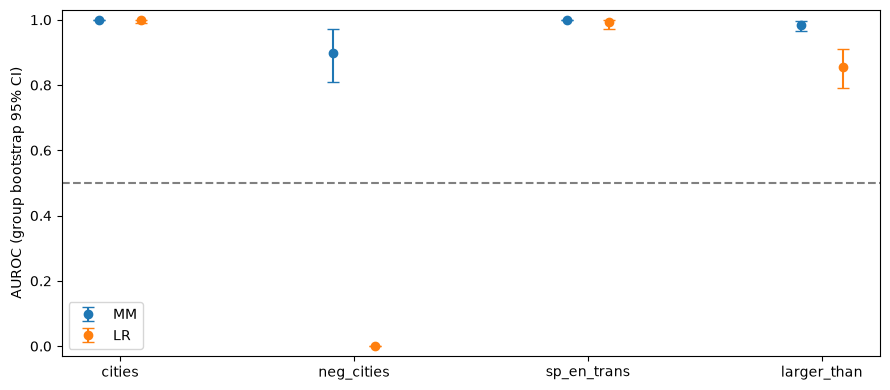

In [4]:
final=pd.DataFrame(result["results"])
display(final[["probe","layer","domain","n","groups","auroc","balanced_accuracy","auroc_ci"]])
fig,ax=plt.subplots(figsize=(9,4))
domains=list(df.domain.unique())
for j,kind in enumerate(["MM","LR"]):
    part=final[final.probe==kind].set_index("domain").loc[domains]
    mean=part.auroc.to_numpy()
    ci=np.array(part.auroc_ci.tolist())
    x=np.arange(len(domains))+(j-.5)*.18
    ax.errorbar(x,mean,yerr=np.maximum(0,np.vstack([mean-ci[:,0],ci[:,1]-mean])),fmt="o",capsize=4,label=kind)
ax.axhline(.5,color="gray",ls="--")
ax.set(xticks=np.arange(len(domains)),xticklabels=domains,ylim=(-.03,1.03),ylabel="AUROC (group bootstrap 95% CI)")
ax.legend();plt.tight_layout();plt.show()

## 신뢰구간은 어떤 불확실성을 포함하는가?

도시/단어/수 쌍을 단위로 resampling했다. 도시·수 비교의 paired 문장을 독립 표본으로 세지 않았다.
이번 번역 표본은 60개 단어에 각 한 문장이다.
이 interval은 **고정된 모델·학습 결과에 조건부인 평가 표본 변동**이다.
다른 seed, 다른 모델, 재학습, layer 선택의 불확실성까지 포함하지 않는다.
neg_cities와 cities는 같은 test 도시를 공유하므로 두 평가의 독립성도 가정하지 않는다.
작은 test에서 완전 분리되면 percentile bootstrap이 [1,1]로 퇴화할 수 있다. 모집단 성능이 확실히 1이라는 뜻은 아니다.

**연습:** AUROC와 balanced accuracy가 서로 다른 이야기를 한다면 threshold 이동과 순위 능력을 구분해 설명하라.

,domain,auroc,balanced_accuracy,accuracy
0,cities,0.547743,0.500000,0.500000
1,neg_cities,0.452257,0.437500,0.437500
2,sp_en_trans,0.588103,0.459596,0.416667
3,larger_than,0.404444,0.500000,0.500000


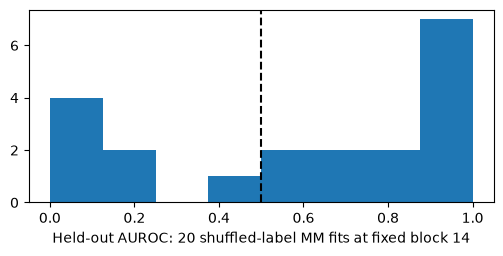

Null range: 0.0 1.0


In [5]:
display(pd.DataFrame(result["token_length_baseline"]))
null=np.array(result["shuffled_label_auroc"])
plt.figure(figsize=(6,2.5));plt.hist(null,bins=8);plt.axvline(.5,color="black",ls="--")
plt.xlabel("Held-out AUROC: 20 shuffled-label MM fits at fixed block 14");plt.show()
print("Null range:",null.min(),null.max())

**주의:** null이 낮다고 모든 shortcut이 사라진 것은 아니다. 길이 baseline도 단 하나의 nuisance control이다.
여기의 label permutation은 행 단위로 쌍 구조를 깨뜨리는 sanity control이며 정식 permutation 유의성 검정이 아니다.
도시/country 분포, tokenization, template, negation, 모델의 fact familiarity가 남아 있다.

## 그림과 정량 결과를 함께 보기
train-only PCA를 test에 투영한다. 가장 예쁜 PCA 그림을 고른 뒤 이를 독립 증거라고 부르지 않는다.

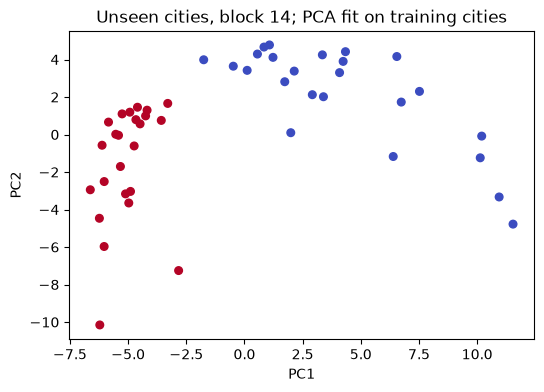

In [6]:
X=acts["layer_14"]
pca=fit_train_pca(X[train],2)
Z=pca.transform(X[test]); labels=df.label.to_numpy()
fig,ax=plt.subplots(figsize=(6,4))
ax.scatter(Z[:,0],Z[:,1],c=labels[test],cmap="coolwarm",s=30)
ax.set(title="Unseen cities, block 14; PCA fit on training cities",xlabel="PC1",ylabel="PC2")
plt.show()

## 직접 해 볼 실험 — 실행 전 설계만 먼저

A. 같은 entity 분할을 유지한 채 문장을 paraphrase하고 성능을 비교한다.
B. 마지막 마침표 대신 첫 token을 읽는 대조군을 만든다.
C. 여러 seed의 train/val split으로 층 선택 안정성을 평가한다.

**최소 보고서:** 데이터 단위, 선택 절차, 대조군, 결과, 가장 그럴듯한 대안 설명, 다음 검증 하나.
새 실험은 이 test를 반복 소비하므로 이미 확인한 결과와 분리해 exploratory로 기록하고,
최종 주장은 별도로 봉인한 새 entity 집합에서 검증한다.

재실행 코드는 `run_truth_pilot.py`다. 모델 다운로드/학습을 자동으로 시작하는 notebook 셀은 없다.

<details><summary>실측 결과 해설 — 먼저 자기 해석을 쓴 뒤 열기</summary>

이 인스턴스의 seed42 pilot에서 LR는 validation으로 block8/C=.01이 선택되었다.
city test AUROC≈.998, neg_cities AUROC=0.000이었다. label 의미를 고정하면
부정문에서 **순위가 뒤집힌 실패**다. test를 본 뒤 부호를 뒤집어 일반화 성공으로 고치면 안 된다.
지리적 연관성 등을 읽었을 가능성은 다음 실험의 가설이며, 이 결과만으로 메커니즘이 확정되지는 않는다.

MM block14는 neg_cities AUROC≈.899이나 balanced accuracy=.50이었다.
순위 정보가 있어도 학습 분포에서 고정한 threshold는 OOD에 맞지 않을 수 있다.
별도 OOD validation에서 threshold를 보정하는 실험은 가능하지만 **zero-shot transfer와 다른 설정**이다.
이 작은 결과를 모든 LR/MM 모델의 우열로 일반화하지 않는다.

</details>

In [7]:
report = {"supported_claim":"", "unsupported_claim":"", "alternative_explanation":"", "next_experiment":""}